In [363]:
# Load the libraries

import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
import time

# Show PyTorch version
torch.__version__

'2.4.0+cu124'

In [364]:
# Setup device agnostic code

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"{device} is in use")

cuda is in use


# Exercise 1

In [365]:
import sklearn

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

In [366]:
# device agnostic code

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [367]:
N_SAMPLES = 1000

In [368]:
X_data, y_data = make_moons(N_SAMPLES, random_state=42)

# turn data into tensors
X_data = torch.from_numpy(X_data).type(torch.float)
y_data = torch.from_numpy(y_data).type(torch.float)

In [369]:
X_data

tensor([[ 0.0087,  0.3682],
        [ 0.9214, -0.4969],
        [ 0.9402, -0.4982],
        ...,
        [ 1.6409, -0.2676],
        [-0.9199,  0.3921],
        [ 0.8008,  0.5989]])

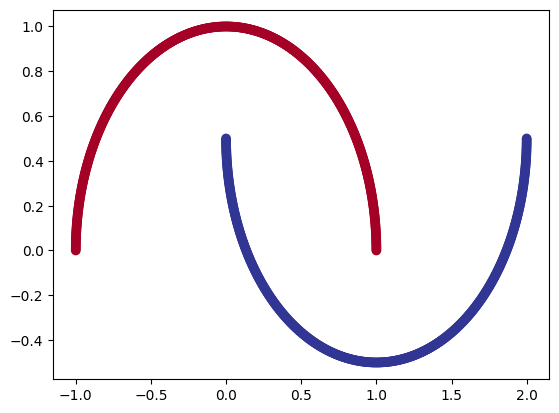

In [370]:
plt.scatter(X_data[:,0], X_data[:,1],c=y_data, cmap="RdYlBu")
plt.show()

In [371]:
X_train, X_test, y_train, y_test = train_test_split(X_data,
                                                    y_data,
                                                    test_size=0.2,
                                                    random_state=int(time.time()))

In [372]:
class MoonModelV1(nn.Module):

    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(in_features=2, out_features=5)
        self.layer2 = nn.Linear(in_features=5, out_features=5)
        self.layer3 = nn.Linear(in_features=5, out_features=5)
        self.layer4 = nn.Linear(in_features=5, out_features=1)
        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()


    def forward(self, x):
        return self.layer4(self.tanh(self.layer3(   self.tanh(   self.layer2( self.tanh(  self.layer1(x)  ) )   )   ) ))

model_1 = MoonModelV1().to(device)

In [373]:
# Setting up loss function and optimizer

loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)

In [374]:
# Calculate accuracy

def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = 100 * correct / len(y_pred)
    return acc

In [375]:
torch.manual_seed(int(time.time()))
torch.cuda.manual_seed(int(time.time()))

# Set the number of epochs
epochs = 700

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Training loop
for epoch in range(epochs):

    ### training
    model_1.train()

    # 1. Forward pass
    y_logits = model_1(X_train).squeeze()
    y_pred =  torch.round(torch.sigmoid(y_logits))

    # 2. Calculate loss/accuracy
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()


    ### TESTING
    model_1.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_1(X_test).squeeze()
        test_pred   = torch.round(torch.sigmoid(test_logits)) 

        # 2. Calculate loss/accuracy
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

        if epoch > 1 and epoch % 100 == 0:
            print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

    

Epoch: 100 | Loss: 0.42270, Acc: 83.38% | Test Loss: 0.43607, Test Acc: 80.00%
Epoch: 200 | Loss: 0.25913, Acc: 89.75% | Test Loss: 0.29816, Test Acc: 86.50%
Epoch: 300 | Loss: 0.24985, Acc: 89.88% | Test Loss: 0.29369, Test Acc: 86.50%
Epoch: 400 | Loss: 0.24613, Acc: 89.88% | Test Loss: 0.29003, Test Acc: 87.00%
Epoch: 500 | Loss: 0.24294, Acc: 89.88% | Test Loss: 0.28654, Test Acc: 87.50%
Epoch: 600 | Loss: 0.23976, Acc: 89.75% | Test Loss: 0.28327, Test Acc: 87.50%


In [376]:
import requests
from pathlib import Path
import matplotlib.pyplot as plt

# Download helper functions from Learn PyTorch repo
if Path("helper_functions.py").is_file():
    print("helper_functions.py already exists, skipping downloading")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping downloading


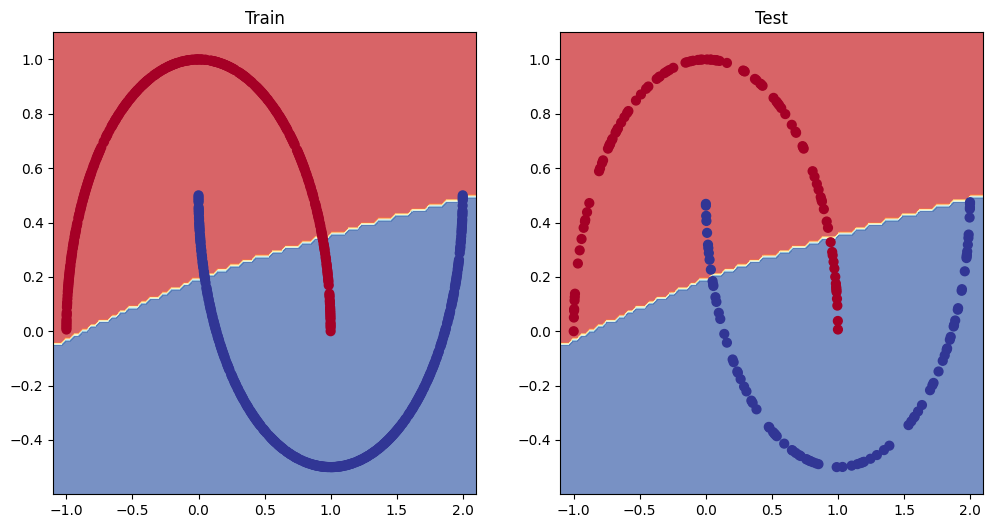

In [377]:
# Plot decision boundary on the model

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

# Multiclass classification

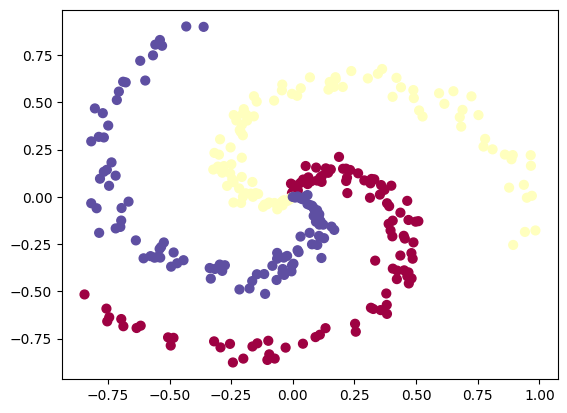

In [417]:
# Code for creating a spiral dataset from CS231n
import numpy as np
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

In [465]:
# turn data into tensors
X_data = torch.from_numpy(X).type(torch.float)
y_data = torch.from_numpy(y).type(torch.LongTensor)

X_train, X_test, y_train, y_test = train_test_split(X_data,
                                                    y_data,
                                                    test_size=0.2,
                                                    random_state=int(time.time()))

In [466]:
class Spirals_Model_V1(nn.Module):

    def __init__(self, input_features, output_features, hidden_units=10):
        super().__init__()
        self.linear_layers_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.Tanh(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features)
        )

    def forward(self, x):
        return self.linear_layers_stack(x)
    
model_2 = Spirals_Model_V1(
    input_features = 2,
    output_features = 3,
    hidden_units = 10
).to(device)

In [467]:
# loss function and optimizer

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                            lr=0.2)

In [468]:
# Fit the model
torch.manual_seed(42)

# Set number of epochs
epochs = 800

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    ### Training
    model_2.train()

    # 1. Forward pass
    y_logits = model_2(X_train) # model outputs raw logits 
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # go from logits -> prediction probabilities -> prediction labels
    # print(y_logits)
    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_train) 
    acc = accuracy_fn(y_true=y_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_2.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_logits = model_2(X_test)
      test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
      # 2. Calculate test loss and accuracy
      test_loss = loss_fn(test_logits, y_test)
      test_acc = accuracy_fn(y_true=y_test,
                             y_pred=test_pred)

    # Print out what's happening
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%") 

Epoch: 0 | Loss: 1.09332, Acc: 35.83% | Test Loss: 1.09042, Test Acc: 33.33%
Epoch: 100 | Loss: 0.89708, Acc: 53.33% | Test Loss: 0.86020, Test Acc: 60.00%
Epoch: 200 | Loss: 0.66363, Acc: 59.17% | Test Loss: 0.59712, Test Acc: 60.00%
Epoch: 300 | Loss: 0.59853, Acc: 71.67% | Test Loss: 0.55184, Test Acc: 75.00%
Epoch: 400 | Loss: 0.46165, Acc: 80.83% | Test Loss: 0.44719, Test Acc: 85.00%
Epoch: 500 | Loss: 0.30042, Acc: 87.92% | Test Loss: 0.32480, Test Acc: 88.33%
Epoch: 600 | Loss: 0.20986, Acc: 92.92% | Test Loss: 0.25740, Test Acc: 88.33%
Epoch: 700 | Loss: 0.15082, Acc: 95.00% | Test Loss: 0.20441, Test Acc: 88.33%


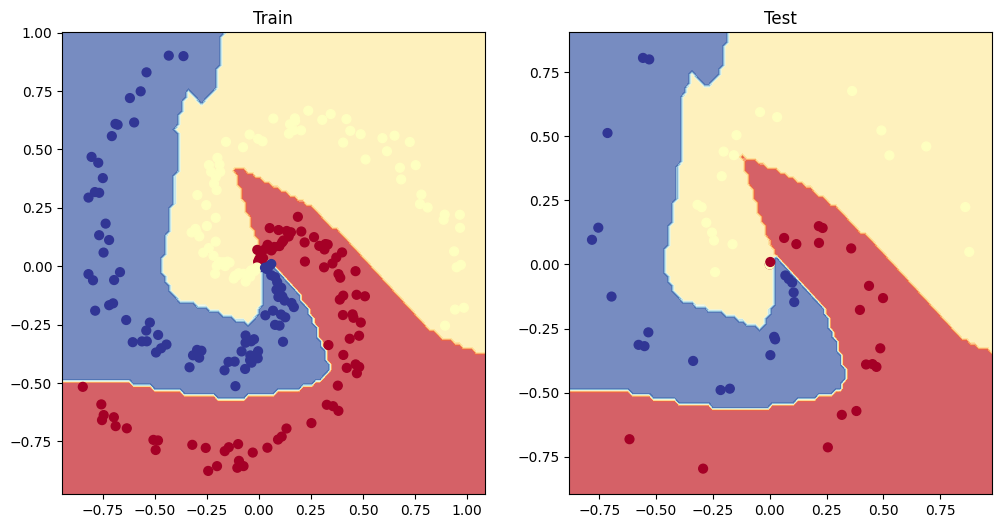

In [469]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_2, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_2, X_test, y_test)